In [ ]:
!pip install numpy pandas matplotlib seaborn scikit-learn xgboost 


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [91]:
!pip install imblearn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: C:\Users\Dell\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
     - -------------------------------------- 10.2/235.4 kB ? eta -:--:--
     ----- --------------------------------- 30.7/235.4 kB 1.4 MB/s eta 0:00:01
     ----------- ------------------------- 71.7/235.4 kB 787.7 kB/s eta 0:00:01
     ------------------- ------------------ 122.9/235.4 kB 1.0 MB/s eta 0:00:01
     ---------------------------- --------- 174.1/235.4 kB 1.1 MB/s eta 0:00:01
     ------------------------------------ - 225.3/235.4 kB 1.1 MB/s eta 0:00:01
     -------------------------------------- 235.4/235.4 kB 1.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [97]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split



In [4]:
df = pd.read_csv("../data/german_credit_data.csv")
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [14]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


## Initial Observations

- Dataset contains customers mostly aged between 25–45
- Credit amount varies significantly (possible strong predictor)
- Loan duration ranges from short to long-term
- Job category indicates different employment levels

In [15]:
df.describe(include="object")

,Sex,Housing,Saving accounts,Checking account,Purpose,Risk
count,1000,1000,817,606,1000,1000
unique,2,3,4,3,8,2
top,male,own,little,little,car,good
freq,690,713,603,274,337,700


## Categorical Feature Insights

- Dataset is dominated by male customers
- Majority of customers own housing
- Significant missing values in checking accounts (~40%)
- Missing values treated as "unknown"
- Loan purpose varies across multiple categories
- Slight imbalance in target variable

In [12]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

# Data Cleaning 

In [5]:
df =df.drop("Unnamed: 0", axis=1)

In [64]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [9]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [21]:
df['Saving accounts'].value_counts()

Saving accounts
little        603
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

In [22]:
df['Checking account'].value_counts()


Checking account
little      274
moderate    269
rich         63
Name: count, dtype: int64

In [6]:
#Handling missing values in "Saving accounts" and "Checking account" columns by replacing them with "unknown"
df["Saving accounts"] = df["Saving accounts"].fillna("Unknown")
df["Checking account"] = df["Checking account"].fillna("Unknown")

In [25]:
df.isnull().sum()

Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

# Basic Data Visuallisation

<Axes: xlabel='Risk', ylabel='count'>

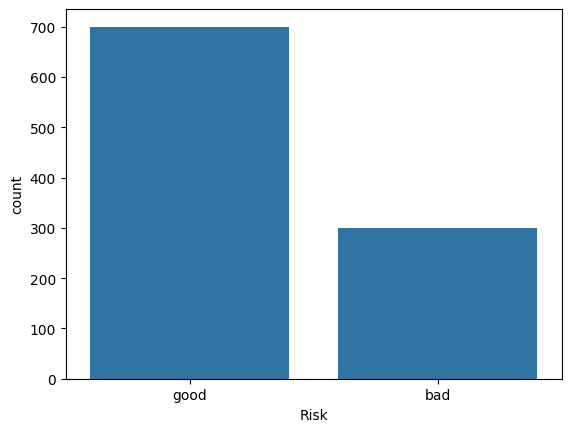

In [8]:
sns.countplot(x="Risk", data=df)

<Axes: xlabel='Risk', ylabel='Credit amount'>

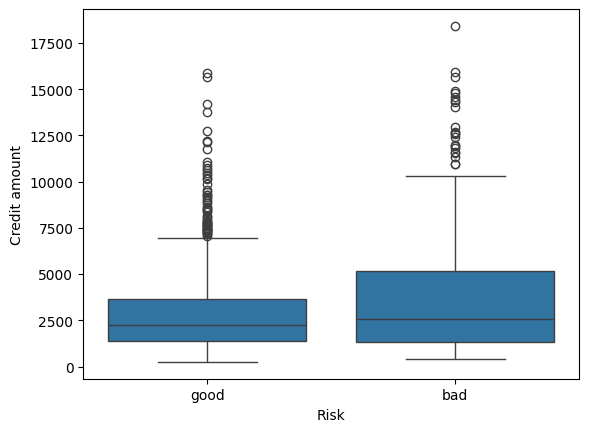

In [28]:
sns.boxplot(x="Risk", y="Credit amount", data=df)

<Axes: xlabel='Risk', ylabel='Duration'>

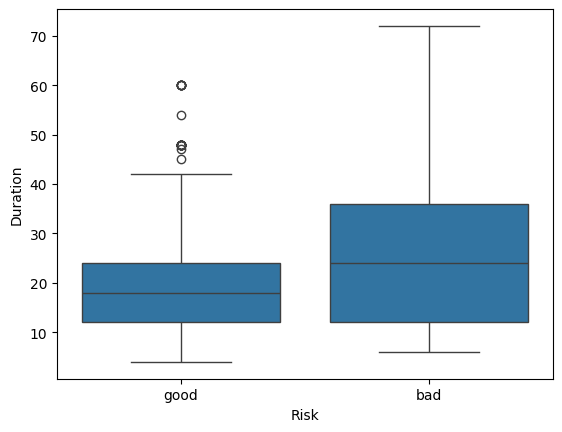

In [29]:
sns.boxplot(x="Risk", y="Duration", data=df)

<Axes: xlabel='Sex', ylabel='count'>

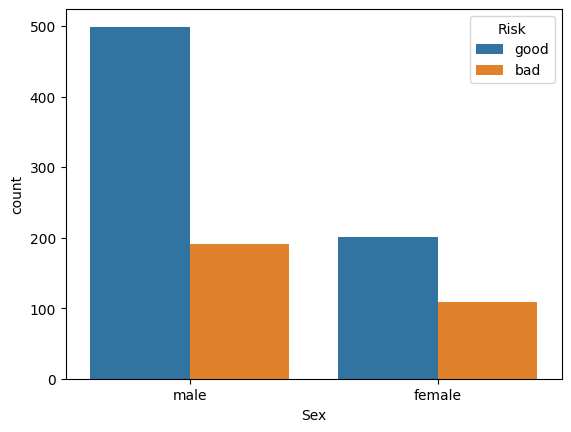

In [31]:
sns.countplot(x="Sex", hue="Risk", data=df)


<Axes: xlabel='Housing', ylabel='count'>

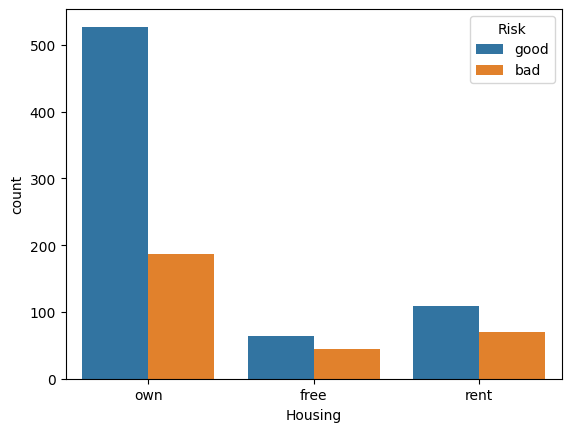

In [32]:
sns.countplot(x="Housing", hue="Risk", data=df)

<Axes: xlabel='Purpose', ylabel='count'>

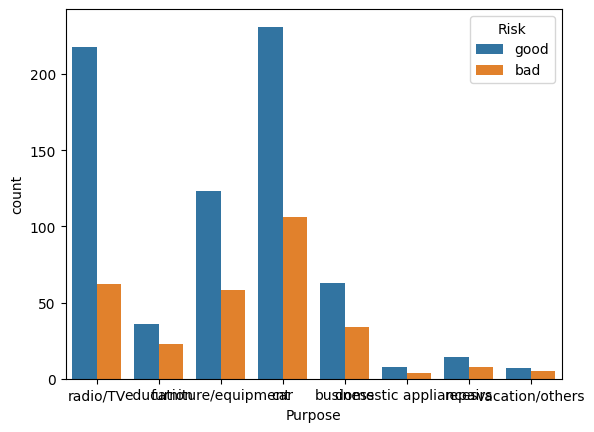

In [33]:
sns.countplot(x="Purpose", hue="Risk", data=df)

<Axes: >

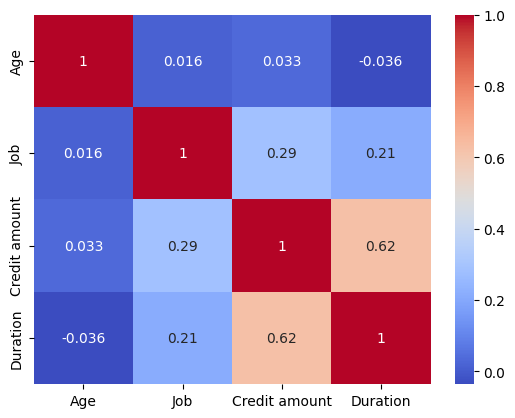

In [34]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

<Axes: xlabel='Credit amount', ylabel='Count'>

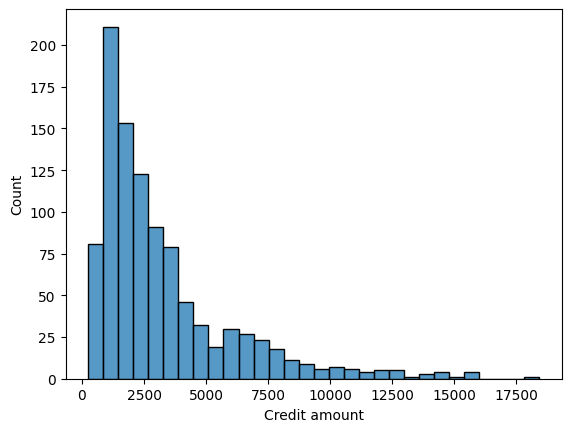

In [35]:
sns.histplot(df["Credit amount"], bins=30)

#  **Numerical Screening**

In [7]:
df['Risk'] = df["Risk"].map({"good":1, "bad":0})

In [20]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,Unknown,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,Unknown,1736,12,furniture/equipment,1
996,40,male,3,own,little,little,3857,30,car,1
997,38,male,2,own,little,Unknown,804,12,radio/TV,1
998,23,male,2,free,little,little,1845,45,radio/TV,0


In [8]:
nums_cols = df.select_dtypes(include=["int64", "float64"]).columns.drop("Risk")

In [9]:
nums_cols

Index(['Age', 'Job', 'Credit amount', 'Duration'], dtype='object')

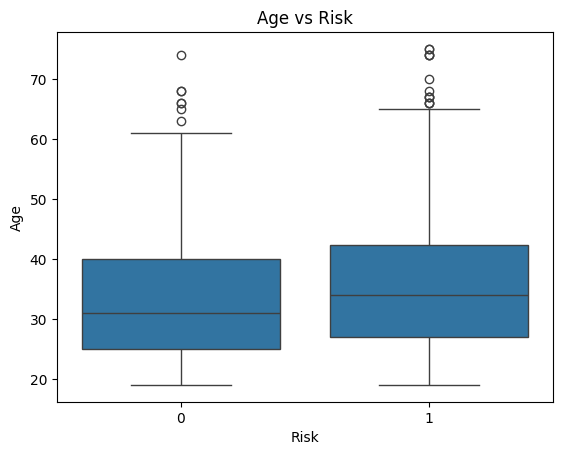

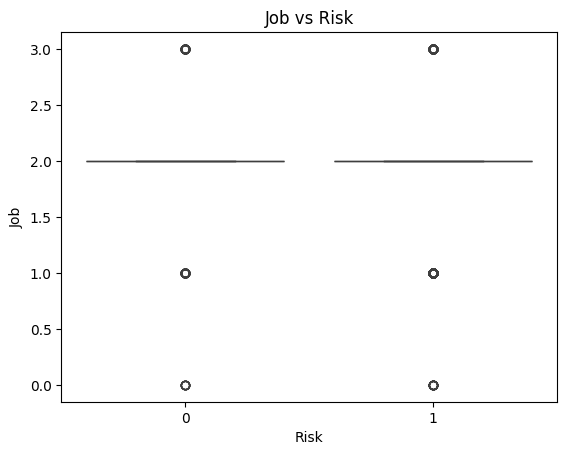

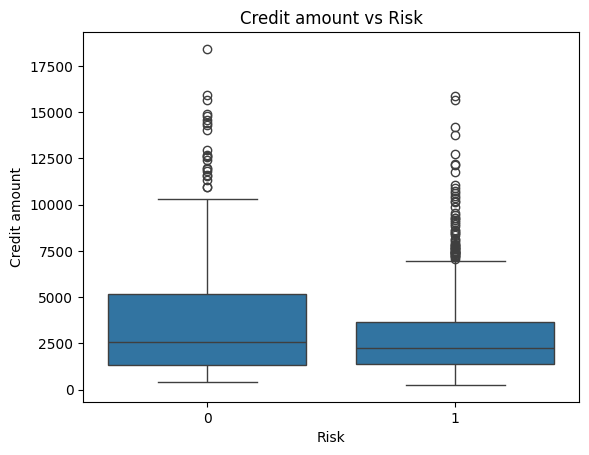

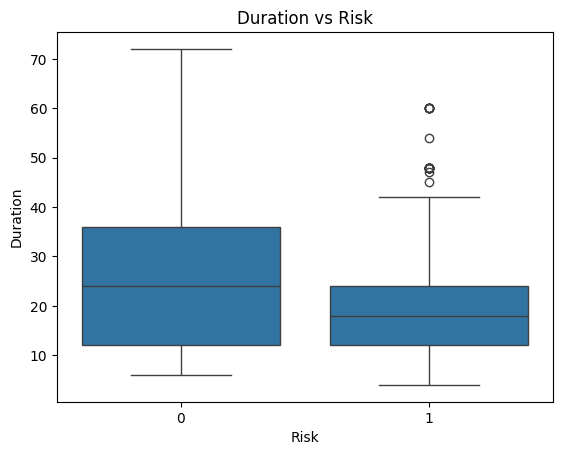

In [23]:
for col in nums_cols:
    sns.boxplot(x="Risk", y=col, data=df)
    plt.title(f"{col} vs Risk")
    plt.show()
    

In [16]:
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

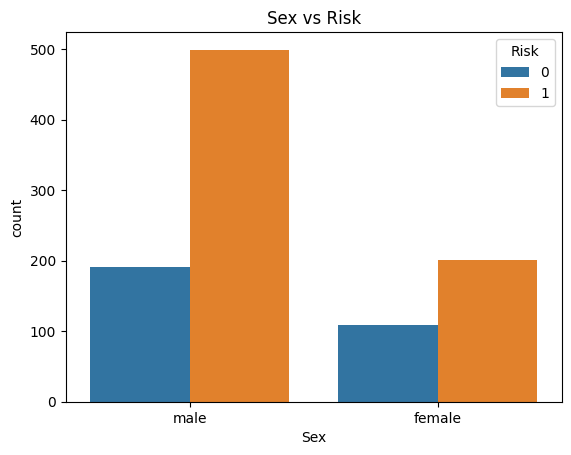

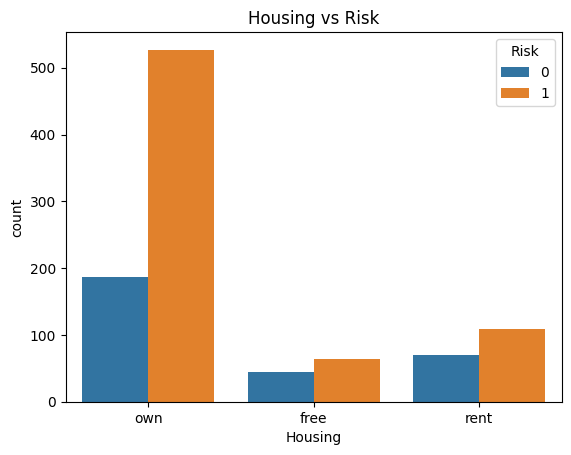

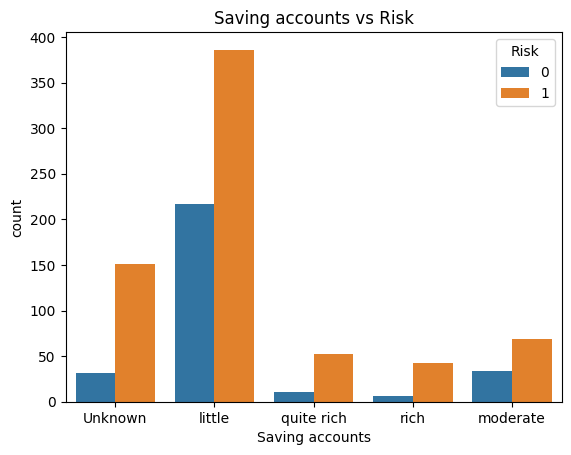

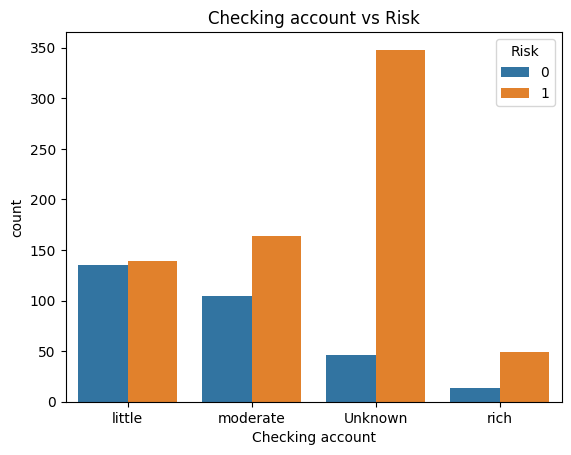

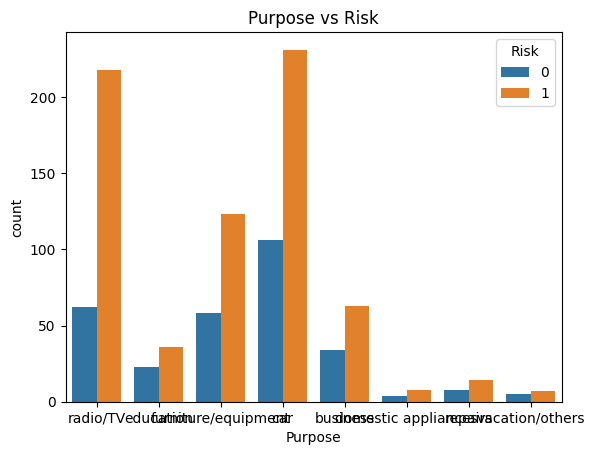

In [17]:
for col in cat_cols:
    sns.countplot(x=col, hue="Risk", data=df)
    plt.title(f"{col} vs Risk")
    plt.show()

In [18]:
df.corr(numeric_only=True)['Risk'].sort_values()

Duration        -0.214927
Credit amount   -0.154739
Job             -0.032735
Age              0.091127
Risk             1.000000
Name: Risk, dtype: float64

In [19]:
for col in cat_cols:
    print(col)
    print(pd.crosstab(df[col], df["Risk"], normalize="index"))

Sex
Risk           0         1
Sex                       
female  0.351613  0.648387
male    0.276812  0.723188
Housing
Risk            0         1
Housing                    
free     0.407407  0.592593
own      0.260870  0.739130
rent     0.391061  0.608939
Saving accounts
Risk                    0         1
Saving accounts                    
Unknown          0.174863  0.825137
little           0.359867  0.640133
moderate         0.330097  0.669903
quite rich       0.174603  0.825397
rich             0.125000  0.875000
Checking account
Risk                     0         1
Checking account                    
Unknown           0.116751  0.883249
little            0.492701  0.507299
moderate          0.390335  0.609665
rich              0.222222  0.777778
Purpose
Risk                        0         1
Purpose                                
business             0.350515  0.649485
car                  0.314540  0.685460
domestic appliances  0.333333  0.666667
education            0.38

In [20]:
X = pd.get_dummies(df.drop("Risk", axis=1), drop_first=True)
y = df["Risk"]

In [21]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(39))

Credit amount                  0.228855
Age                            0.183336
Duration                       0.158634
Checking account_little        0.069150
Job                            0.060440
Checking account_moderate      0.039864
Saving accounts_little         0.036155
Sex_male                       0.032544
Purpose_car                    0.027856
Housing_own                    0.025684
Purpose_radio/TV               0.023231
Purpose_furniture/equipment    0.021288
Housing_rent                   0.016498
Saving accounts_moderate       0.015600
Purpose_education              0.013624
Checking account_rich          0.011052
Purpose_repairs                0.009581
Saving accounts_rich           0.009543
Saving accounts_quite rich     0.009296
Purpose_vacation/others        0.004686
Purpose_domestic appliances    0.003083
dtype: float64


# Training the Base line model first wothout any feature engineering or anything 

In [23]:
# seperating the target from the dataset 
X= df.drop("Risk", axis=1)
y=df["Risk"]

In [ ]:
# First of all we need to incode and the categorical varibles and then we can apply the model to find the feature importance. we can use the get_dummies function to encodet the catgorical variables 
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size = 0.2, random_state = 42)

Encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_encoded = Encoder.fit_transform(X_train[cat_cols])
X_test_encoded = Encoder.transform(X_test[cat_cols])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=Encoder.get_feature_names_out(cat_cols), index= X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=Encoder.get_feature_names_out(cat_cols), index= X_test.index)

X_train_final = pd.concat([X_train.drop(cat_cols, axis=1), X_train_encoded_df], axis=1)
X_test_final = pd.concat([X_test.drop(cat_cols, axis=1), X_test_encoded_df], axis =1)

In [ ]:

# models ={
#     "LogisticRegression": LogisticRegression(max_iter=1000),
#     "RandomForestClassifier": RandomForestClassifier(n_estimators=100, random_state=42),
#     "svn" :SVC(),
#     "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
# }

# for name , model in models.items():
#     model.fit(X_train_final, y_train)
#     y_pred = model.predict(X_test_final)
#     print(f"Model: {name}")
#     print(classification_report(y_test, y_pred))

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.63      0.41      0.49        59
           1       0.78      0.90      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.65      0.67       200
weighted avg       0.74      0.76      0.74       200

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.62      0.47      0.54        59
           1       0.80      0.88      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200

Model: svn
              precision    recall  f1-score   support

           0       0.75      0.05      0.10        59
           1       0.71      0.99      0.83       141

    accuracy                           0.71       200
   macro avg       0.73      0.52      0.46       200
weighte

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [12:55:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.64      0.47      0.54        59
           1       0.80      0.89      0.84       141

    accuracy                           0.77       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.77      0.75       200



# Feature Engineeiring 

In [56]:
df_engg = df.copy()

In [57]:
df_engg["Credit_Per_Month"] = df_engg["Credit amount"] / df_engg["Duration"]
df_engg['Checking account'].unique()

array(['little', 'moderate', 'Unknown', 'rich'], dtype=object)

In [58]:
df_engg["Saving groups"] = df_engg['Saving accounts'].replace({"Unknown": "Unknown", "little": "Low", "moderate": "Medium", "quite rich": "High", "rich": "High"})
df_engg["Checking groups"] = df_engg['Checking account'].replace({"Unknown":"Unknown", 'little': 'low', 'moderate': 'medium', "rich":"high"})
df_engg["Age_group"] = pd.cut(df_engg["Age"], bins=[0, 25, 35, 60, np.inf], labels=["Young", "Adult", "Senior", "Elderly"])

In [59]:
df_engg.drop(["Saving accounts", "Checking account"], axis=1, inplace=True)
df_engg.head()

,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk,Credit_Per_Month,Saving groups,Checking groups,Age_group
0,67,male,2,own,1169,6,radio/TV,1,194.833333,Unknown,low,Elderly
1,22,female,2,own,5951,48,radio/TV,0,123.979167,Low,medium,Young
2,49,male,1,own,2096,12,education,1,174.666667,Low,Unknown,Senior
3,45,male,2,free,7882,42,furniture/equipment,1,187.666667,Low,low,Senior
4,53,male,2,free,4870,24,car,0,202.916667,Low,low,Senior


In [60]:
df_engg.head()

,Age,Sex,Job,Housing,Credit amount,Duration,Purpose,Risk,Credit_Per_Month,Saving groups,Checking groups,Age_group
0,67,male,2,own,1169,6,radio/TV,1,194.833333,Unknown,low,Elderly
1,22,female,2,own,5951,48,radio/TV,0,123.979167,Low,medium,Young
2,49,male,1,own,2096,12,education,1,174.666667,Low,Unknown,Senior
3,45,male,2,free,7882,42,furniture/equipment,1,187.666667,Low,low,Senior
4,53,male,2,free,4870,24,car,0,202.916667,Low,low,Senior


In [61]:
X_engg = df_engg.drop("Risk", axis =1)
y_engg = df_engg["Risk"]

In [62]:
cat_cols_engg = X_engg.select_dtypes(include=['object','category']).columns


In [63]:
cat_cols_engg

Index(['Sex', 'Housing', 'Purpose', 'Saving groups', 'Checking groups',
       'Age_group'],
      dtype='object')

In [64]:
X_engg_train, X_engg_test, y_engg_train, y_engg_test = train_test_split(X_engg, y_engg , test_size = 0.2, random_state = 42)

In [65]:
X_engg_train_encoded = Encoder.fit_transform(X_engg_train[cat_cols_engg])
X_engg_test_encoded = Encoder.transform(X_engg_test[cat_cols_engg])

X_engg_train_encoded_df = pd.DataFrame(X_engg_train_encoded, columns=Encoder.get_feature_names_out(cat_cols_engg), index= X_engg_train.index)
X_engg_test_encoded_df = pd.DataFrame(X_engg_test_encoded, columns=Encoder.get_feature_names_out(cat_cols_engg), index= X_engg_test.index)

X_engg_train_final = pd.concat([X_engg_train.drop(cat_cols_engg, axis=1), X_engg_train_encoded_df], axis=1)
X_engg_test_final = pd.concat([X_engg_test.drop(cat_cols_engg, axis=1), X_engg_test_encoded_df], axis =1)

X_engg_test_final

,Age,Job,Credit amount,Duration,Credit_Per_Month,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,...,Saving groups_Medium,Saving groups_Unknown,Checking groups_Unknown,Checking groups_high,Checking groups_low,Checking groups_medium,Age_group_Adult,Age_group_Elderly,Age_group_Senior,Age_group_Young
521,24,2,3190,18,177.222222,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
737,35,1,4380,18,243.333333,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
740,32,2,2325,24,96.875000,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
660,23,2,1297,12,108.083333,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
411,35,3,7253,33,219.787879,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,26,3,3235,24,134.791667,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
332,24,3,7408,60,123.466667,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,21,1,6568,24,273.666667,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
613,22,2,3632,24,151.333333,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# models ={
#     "LogisticRegression": LogisticRegression(max_iter=1000),
#     "RandomForestClassifier": RandomForestClassifier(class_weight="balanced", random_state=42),
#     "svn" :SVC(),
#     "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
# }


In [73]:
for name , model in models.items():
    model.fit(X_engg_train_final, y_engg_train)
    y_pred = model.predict(X_engg_test_final)
    print(f"Model: {name}")
    print(classification_report(y_engg_test, y_pred))

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: LogisticRegression
              precision    recall  f1-score   support

           0       0.67      0.44      0.53        59
           1       0.80      0.91      0.85       141

    accuracy                           0.77       200
   macro avg       0.73      0.67      0.69       200
weighted avg       0.76      0.77      0.75       200

Model: RandomForestClassifier
              precision    recall  f1-score   support

           0       0.70      0.44      0.54        59
           1       0.80      0.92      0.86       141

    accuracy                           0.78       200
   macro avg       0.75      0.68      0.70       200
weighted avg       0.77      0.78      0.76       200

Model: svn
              precision    recall  f1-score   support

           0       0.75      0.05      0.10        59
           1       0.71      0.99      0.83       141

    accuracy                           0.71       200
   macro avg       0.73      0.52      0.46       200
weighte

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [13:04:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: XGBClassifier
              precision    recall  f1-score   support

           0       0.62      0.47      0.54        59
           1       0.80      0.88      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



In [81]:
df2 = df.copy()

In [82]:
df2

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,Unknown,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,0
2,49,male,1,own,little,Unknown,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,0
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,Unknown,1736,12,furniture/equipment,1
996,40,male,3,own,little,little,3857,30,car,1
997,38,male,2,own,little,Unknown,804,12,radio/TV,1
998,23,male,2,free,little,little,1845,45,radio/TV,0


In [77]:
df2_cat = df2.select_dtypes(include=["object", "category"]).columns
df2_cat

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [84]:
X2 = df2.drop("Risk", axis=1)
y2 = df2["Risk"]

In [85]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [86]:
X2_train = Encoder.fit_transform(X2_train[cat_cols])
X2_test = Encoder.transform(X2_test[cat_cols])

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.]], shape=(800, 22))

In [90]:
for name, model in models.items():
    model.fit(X2_train, y2_train)
    y2_pred = model.predict(X2_test)
    print(f"{name}: {classification_report(y2_test, y2_pred)}")
    print(f"{name}: {accuracy_score(y2_test, y2_pred)}")

LogisticRegression:               precision    recall  f1-score   support

           0       0.55      0.29      0.38        59
           1       0.75      0.90      0.82       141

    accuracy                           0.72       200
   macro avg       0.65      0.59      0.60       200
weighted avg       0.69      0.72      0.69       200

LogisticRegression: 0.72
RandomForestClassifier:               precision    recall  f1-score   support

           0       0.47      0.73      0.57        59
           1       0.85      0.65      0.74       141

    accuracy                           0.68       200
   macro avg       0.66      0.69      0.65       200
weighted avg       0.74      0.68      0.69       200

RandomForestClassifier: 0.675
svn:               precision    recall  f1-score   support

           0       0.55      0.27      0.36        59
           1       0.75      0.91      0.82       141

    accuracy                           0.72       200
   macro avg       0.65 

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [13:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier:               precision    recall  f1-score   support

           0       0.50      0.32      0.39        59
           1       0.75      0.87      0.81       141

    accuracy                           0.70       200
   macro avg       0.63      0.59      0.60       200
weighted avg       0.68      0.70      0.68       200

XGBClassifier: 0.705


In [92]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state =42)
X_train_sm, y_train_sm = sm.fit_resample(X_engg_train_final, y_engg_train)

In [118]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=650, class_weight="balanced", random_state=42),
    "RandomForestClassifier": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
    
}

In [120]:
for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    # y_pred_sm = model.predict(X_engg_test_final)
    y_pred_sm_prob = model.predict_proba(X_engg_test_final)[:, 1]
    y_pred_sm = (y_pred_sm_prob >= 0.5).astype(int)
    print(f"{name}: {classification_report(y_engg_test, y_pred_sm)}")

C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 650 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=650).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression:               precision    recall  f1-score   support

           0       0.53      0.68      0.59        59
           1       0.85      0.74      0.79       141

    accuracy                           0.72       200
   macro avg       0.69      0.71      0.69       200
weighted avg       0.75      0.72      0.73       200

RandomForestClassifier:               precision    recall  f1-score   support

           0       0.64      0.47      0.54        59
           1       0.80      0.89      0.84       141

    accuracy                           0.77       200
   macro avg       0.72      0.68      0.69       200
weighted avg       0.75      0.77      0.75       200



C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [13:49:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier:               precision    recall  f1-score   support

           0       0.64      0.49      0.56        59
           1       0.81      0.89      0.84       141

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



In [ ]:
# from sklearn.model_selection import GridSearchCV

# models = {
#     "LogisticRegression": LogisticRegression(max_iter=650, class_weight="balanced", random_state=42),   
#     "RandomForestClassifier": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
#     "XGBClassifier": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
# }

# params = {
#     "LogisticRegression": {
#         "C": [0.01, 0.1, 1, 10, 100],
#         "solver": ["liblinear", "lbfgs"]
#     },
#     "RandomForestClassifier": {
#         "n_estimators": [50, 100, 200],
#         "max_depth": [None, 10, 20],
#         "min_samples_split": [2, 5, 10]
#     },
#     "XGBClassifier": {
#         "n_estimators": [50, 100, 200],
#         "learning_rate": [0.01, 0.1, 0.2],
#         "max_depth": [3, 5, 7]
#     }
# }

# for name , model in models.items():
#     grid = GridSearchCV(estimator=model, param_grid=params[name], cv=5, n_jobs=-1, verbose=2)
#     grid.fit(X_train_sm, y_train_sm)
#     best_model = grid.best_estimator_
#     y_pred_grid_prob = best_model.predict_proba(X_engg_test_final)[:, 1]
#     y_pred_grid = (y_pred_grid_prob >= 0.5).astype(int)
#     print(f"{name} after GridSearchCV: {classification_report(y_engg_test, y_pred_grid)}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 650 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=650).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression after GridSearchCV:               precision    recall  f1-score   support

           0       0.51      0.64      0.57        59
           1       0.83      0.74      0.79       141

    accuracy                           0.71       200
   macro avg       0.67      0.69      0.68       200
weighted avg       0.74      0.71      0.72       200

Fitting 5 folds for each of 27 candidates, totalling 135 fits
RandomForestClassifier after GridSearchCV:               precision    recall  f1-score   support

           0       0.59      0.46      0.51        59
           1       0.79      0.87      0.83       141

    accuracy                           0.74       200
   macro avg       0.69      0.66      0.67       200
weighted avg       0.73      0.74      0.73       200

Fitting 5 folds for each of 27 candidates, totalling 135 fits


C:\Users\Dell\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\xgboost\training.py:200: UserWarning: [13:59:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier after GridSearchCV:               precision    recall  f1-score   support

           0       0.62      0.49      0.55        59
           1       0.80      0.87      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.68      0.69       200
weighted avg       0.75      0.76      0.75       200



In [126]:
grid.best_params_

{'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}

In [128]:
from sklearn.model_selection import GridSearchCV

params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(RandomForestClassifier(class_weight="balanced"),
                    params, cv=5, scoring="f1")

grid.fit(X_train_sm, y_train_sm)

best_model = grid.best_estimator_

y_pred_sm = best_model.predict(X_engg_test_final)

print(grid.best_params_)

print(grid.best_estimator_)

print(grid.best_estimator_.feature_importances_)

print(classification_report(y_engg_test, y_pred_sm))

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
RandomForestClassifier(class_weight='balanced', min_samples_split=5)
[0.0624054  0.02764455 0.09480343 0.08424029 0.08635958 0.01621281
 0.0196436  0.01767583 0.0404423  0.01619715 0.01632861 0.01796297
 0.00188725 0.00982036 0.0162854  0.03461443 0.00528657 0.00242432
 0.0117636  0.04487746 0.0127942  0.02368781 0.12987633 0.00979965
 0.06994743 0.04320239 0.02332919 0.00509514 0.02068195 0.03471001]
              precision    recall  f1-score   support

           0       0.58      0.49      0.53        59
           1       0.80      0.85      0.82       141

    accuracy                           0.74       200
   macro avg       0.69      0.67      0.68       200
weighted avg       0.74      0.74      0.74       200

